In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

2026-06-04 10:38:16.917113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780569497.169377      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780569497.233424      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780569497.827489      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780569497.827540      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780569497.827545      58 computation_placer.cc:177] computation placer alr

In [4]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()
x_train.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

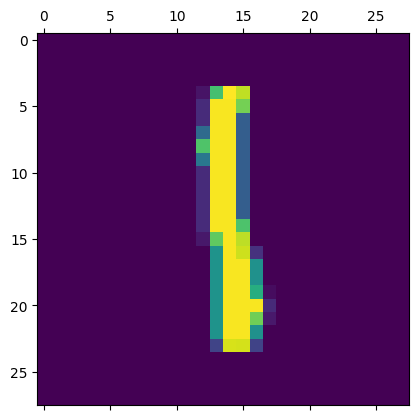

In [6]:
plt.matshow(x_train[1548])

In [8]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [9]:
def plot_data(X,y,index):
    plt.matshow(X[index])
    plt.xlabel(y[index])
    plt.show()

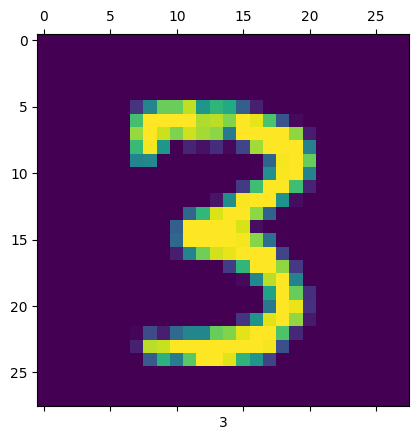

In [11]:
plot_data(x_train,y_train,18964)

In [19]:
#without scaling 

import tensorflow as tf
from tensorflow.keras import layers, models

# CNN Model
cnn = models.Sequential([
    
    layers.Conv2D(
        filters=10,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),
    
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(
        filters=10,
        kernel_size=(3,3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(40, activation='relu'),
    layers.Dense(50, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

cnn.evaluate(x_test, y_test)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9044 - loss: 0.4130
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9714 - loss: 0.0961
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9780 - loss: 0.0734
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9805 - loss: 0.0655
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9840 - loss: 0.0536
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9846 - loss: 0.0516
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9857 - loss: 0.0491
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9864 - loss: 0.0461
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9873 - loss: 0.0430
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9880 - loss: 0.0417
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9825 - loss: 0.0733


[0.07330036908388138, 0.9825000166893005]

In [21]:
y_pred = cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [22]:
y_pred = [np.argmax(i) for i in y_pred]
y_pred[0]

np.int64(7)

In [24]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.96      0.99      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Text(220.72222222222223, 0.5, 'y_pred')

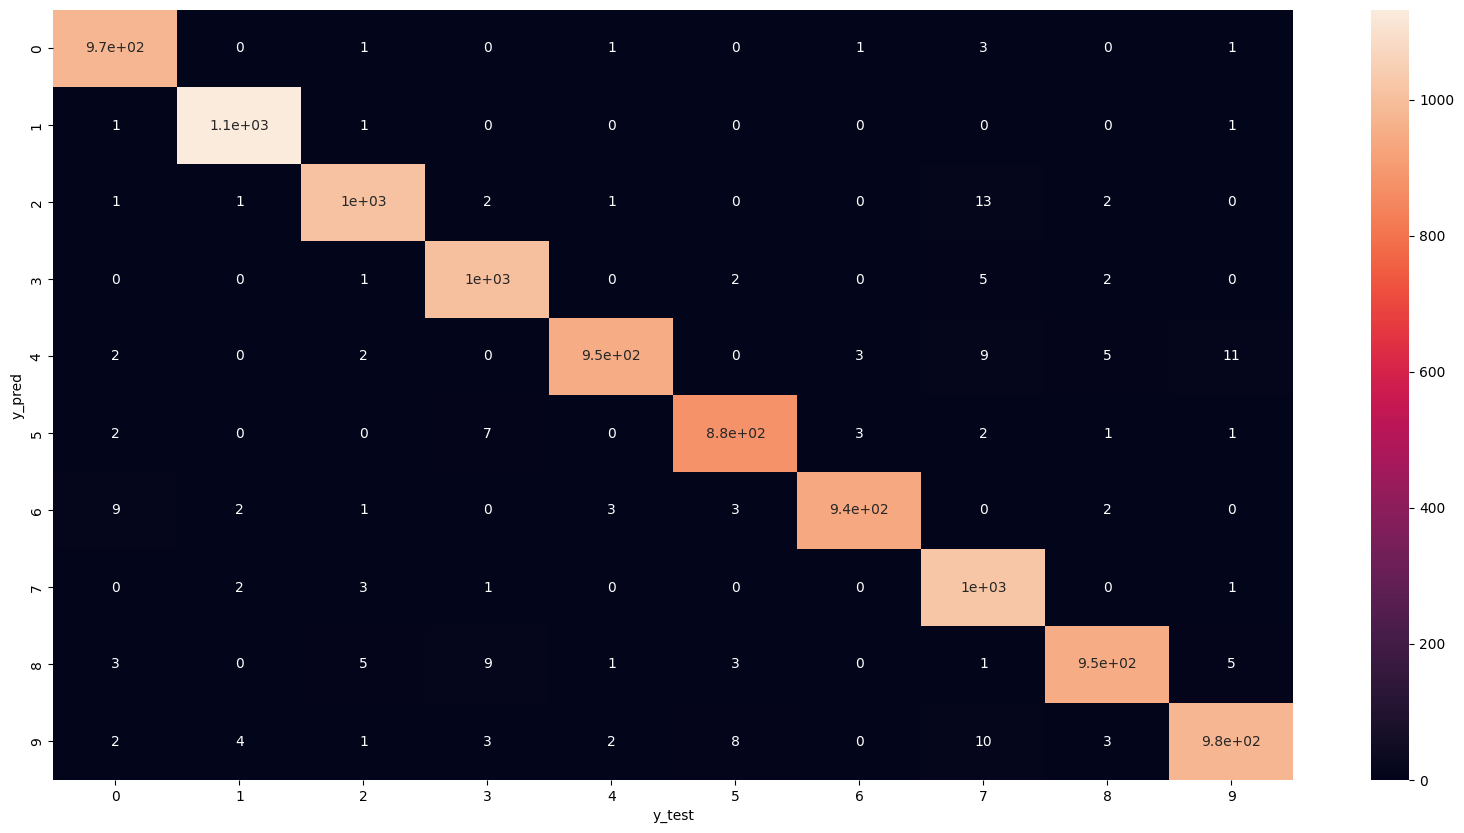

In [26]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(20,10))
sns.heatmap(cm,annot=True)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [28]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.cifar10.load_data()
x_train.shape

(50000, 32, 32, 3)

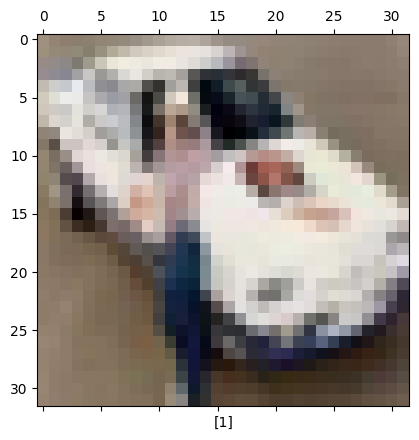

In [29]:
plot_data(x_train,y_train,1548)

In [31]:
#without scaling 

import tensorflow as tf
from tensorflow.keras import layers, models

# CNN Model
cnn1 = models.Sequential([
    
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu'
    ),
    
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(400, activation='relu'),
    layers.Dense(500, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])

cnn1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn1.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

cnn1.evaluate(x_test, y_test)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.3348 - loss: 1.9196
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.4895 - loss: 1.4455
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.5570 - loss: 1.2895
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.5953 - loss: 1.1781
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.6348 - loss: 1.0787
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.6660 - loss: 0.9918
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.6922 - loss: 0.9144
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.7193 - loss: 0.8490
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - accuracy: 0.7419 - loss: 0.7818
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.7696 - loss: 0.7028
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6147 - loss: 1.3517


[1.351722240447998, 0.6147000193595886]

In [32]:
y_pred = cnn1.predict(x_test)
y_pred = [np.argmax(i) for i in y_pred]
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


np.int64(3)

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.60      0.67      1000
           1       0.86      0.64      0.73      1000
           2       0.52      0.49      0.50      1000
           3       0.39      0.52      0.44      1000
           4       0.49      0.65      0.56      1000
           5       0.52      0.55      0.53      1000
           6       0.78      0.61      0.69      1000
           7       0.81      0.58      0.68      1000
           8       0.65      0.78      0.71      1000
           9       0.67      0.73      0.70      1000

    accuracy                           0.61     10000
   macro avg       0.64      0.61      0.62     10000
weighted avg       0.64      0.61      0.62     10000



Text(220.72222222222223, 0.5, 'y_pred')

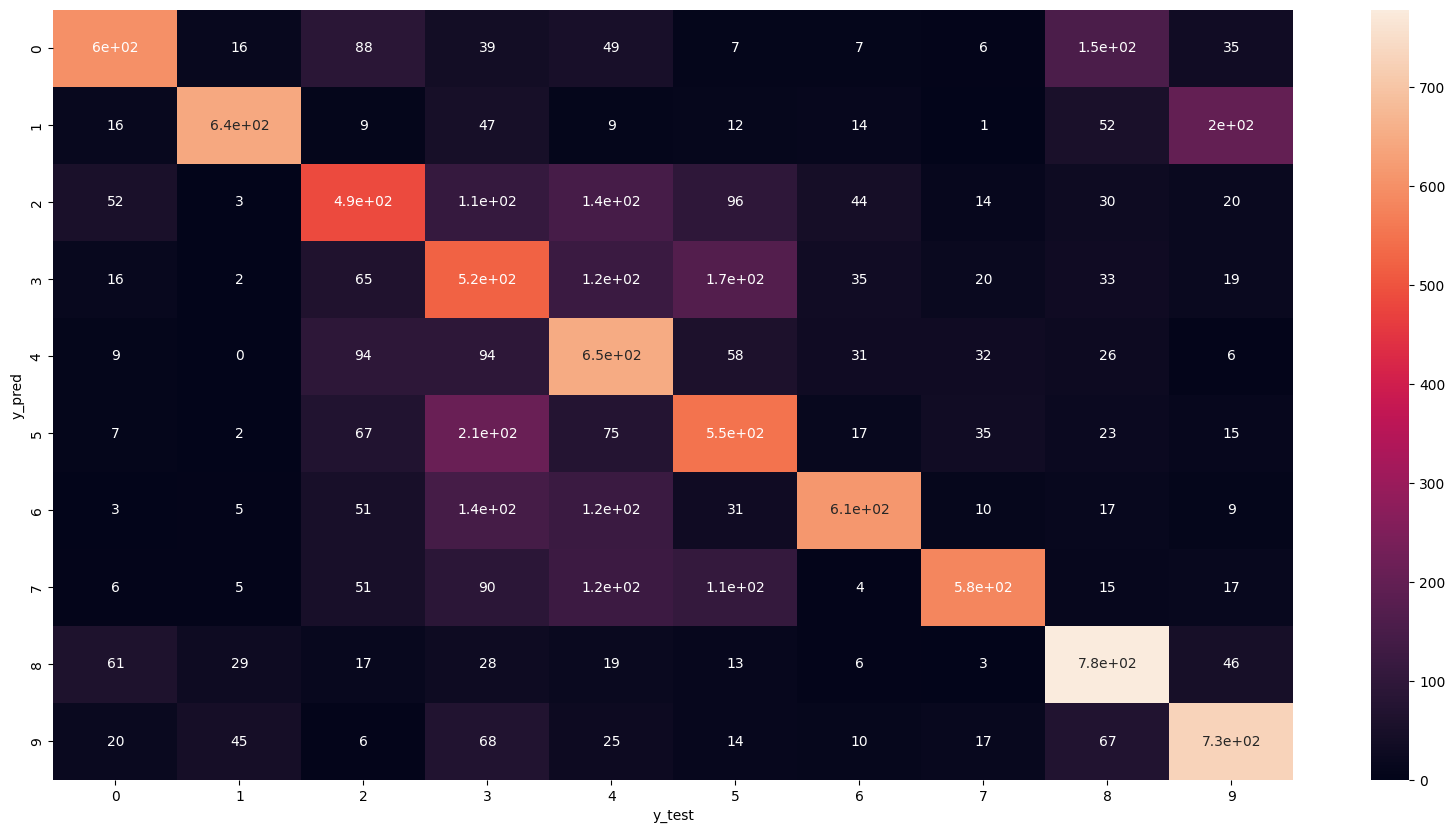

In [34]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(20,10))
sns.heatmap(cm,annot=True)
plt.xlabel('y_test')
plt.ylabel('y_pred')